# Assemble Datasets for Training and Testing

This notebook aims at creating five different datasets:

- random one: upper bound of performance
- hardest ones: novel linker, novel e3 and novel poi
- last three:
  - novel linker only
  - novel e3 only
  - novel poi only

**IMPORTANT NOTE**: PROTACs and substructures _can_ have the _same_ ID, _i.e._, they might refer to the _same_ molecule but with **removed stereochemistry**.

In [79]:
import os
import sys
from typing import Mapping, Literal, Callable, List, ClassVar, Any, Tuple
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys, rdFMCS, Draw
from rdkit import RDLogger
from rdkit import rdBase
from sklearn.model_selection import train_test_split, GroupShuffleSplit

if 'ipykernel' in sys.modules:
    from IPython.display import display
    from tqdm.auto import tqdm  # for notebooks
else:
    from tqdm import tqdm

def safe_display(*args):
    """Displays content only if running in a Jupyter notebook."""
    if 'ipykernel' in sys.modules:
        display(*args)
    else:
        print(*args)

# Disable the RDKit warnings that pop up when RDKit fails to create molecules
RDLogger.DisableLog("rdApp.*")
blocker = rdBase.BlockLogs()

data_dir = os.path.join(os.getcwd(), 'data')

In [80]:
from protac_splitter.protac_cheminformatics import reassemble_protac
from protac_splitter.evaluation import check_substructs

In [81]:
protacs_splitted_with_directionality = pd.read_csv(os.path.join(data_dir, 'processed', 'protacs_splitted_with_directionality.csv'))
protacs_not_splitted = pd.read_csv(os.path.join(data_dir, 'processed', 'protacs_not_splitted.csv'))
# Print their lenghts
print(f'Number of PROTACs splitted with directionality: {len(protacs_splitted_with_directionality)}')
print(f'Number of PROTACs splitted with directionality: {len(protacs_splitted_with_directionality.dropna())}')
print(f'Number of PROTACs not splitted: {len(protacs_not_splitted)}')

Number of PROTACs splitted with directionality: 2133
Number of PROTACs splitted with directionality: 2090
Number of PROTACs not splitted: 3547


In [82]:
def check_dataframe(df: pd.DataFrame) -> bool:
    tqdm.pandas(desc='Checking dataframe')
    return df.progress_apply(lambda x: check_substructs(
            protac_smiles=x['PROTAC SMILES'],
            poi_smiles=x['POI Ligand SMILES with direction'],
            linker_smiles=x['Linker SMILES with direction'],
            e3_smiles=x['E3 Binder SMILES with direction'],
        ), axis=1)

all_incorrect = protacs_splitted_with_directionality[~check_dataframe(protacs_splitted_with_directionality)]
print('Number of incorrect re-assembled samples:', len(all_incorrect))

Checking dataframe: 100%|██████████████████| 2133/2133 [00:19<00:00, 108.92it/s]

Number of incorrect re-assembled samples: 0


An example of two PROTACs with the same ID, one with removed stereochemistry:
Number of PROTACs with ID 31: 2

Nc1nc2c(c(=O)[nH]1)[n+](Cc1ccc(F)cc1)cn2C1OC(COP(=O)(O)OP(=O)(O)NCCOCCOCCOCCOCCOCCOCCOCCC(=O)Nc2cccc3c2CN(C2CCC(=O)NC2=O)C3=O)C(O)C1O


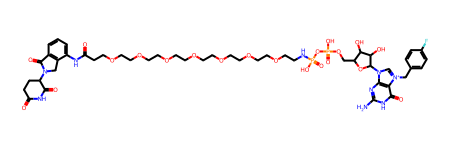

Nc1nc2c(c(=O)[nH]1)[n+](Cc1ccc(F)cc1)cn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O)NCCOCCOCCOCCOCCOCCOCCOCCC(=O)Nc2cccc3c2CN(C2CCC(=O)NC2=O)C3=O)[C@@H](O)[C@H]1O


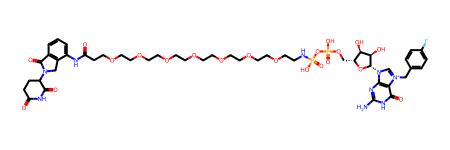

In [83]:
print('An example of two PROTACs with the same ID, one with removed stereochemistry:')
for i in range(1000):
    tmp = protacs_splitted_with_directionality[protacs_splitted_with_directionality['PROTAC ID'] == i]['PROTAC SMILES'].to_list()
    if len(tmp) > 1:
        print(f'Number of PROTACs with ID {i}: {len(tmp)}\n')
        for protac in tmp:
            print(protac)
            safe_display(Chem.MolFromSmiles(protac))
        break

In [84]:
# Check if any of the not splitted PROTACs are in the splitted with directionality
tmp = protacs_not_splitted[protacs_not_splitted['PROTAC SMILES'].isin(protacs_splitted_with_directionality['PROTAC SMILES'])]
print(f'Number of PROTACs not splitted that are in the splitted with directionality: {len(tmp)}')

Number of PROTACs not splitted that are in the splitted with directionality: 0


In [85]:
def get_fingerprint(smiles: str, morgan_fpgen = None, radius: int = 10, fpSize: int = 512) -> np.ndarray:
    """ Get the Morgan fingerprint of a molecule.
    
    Args:
        smiles (str): The SMILES string of the molecule.
        morgan_fpgen: The Morgan fingerprint generator.

    Returns:
        np.ndarray: The Morgan fingerprint.
    """
    if morgan_fpgen is None:
        morgan_fpgen = AllChem.GetMorganGenerator(
            radius=radius,
            fpSize=fpSize,
            includeChirality=True,
        )
    return morgan_fpgen.GetFingerprint(Chem.MolFromSmiles(smiles))

## Reporting Function

In [137]:
def report_dataset(train_df, test_df):
    # total_len = len(protacs_splitted_with_directionality)
    total_len = len(train_df) + len(test_df)

    print(f'Number of PROTACs in the training set: {len(train_df):,} ({len(train_df) / total_len:.1%})')
    print(f'Number of PROTACs in the testing set: {len(test_df):,} ({len(test_df) / total_len:.1%})')

    # Check that there are no same-ID PROTACs in both training and testing sets:
    train_ids = set(train_df['PROTAC SMILES'])
    test_ids = set(test_df['PROTAC SMILES'])
    intersection = train_ids.intersection(test_ids)
    print(f'Number of PROTAC SMILESs that are in both the training and testing sets: {len(intersection)}')

    if 'PROTAC ID' in train_df.columns:
        train_ids = set(train_df['PROTAC ID'])
        test_ids = set(test_df['PROTAC ID'])
        intersection = train_ids.intersection(test_ids)
        print(f'Number of PROTAC IDs that are in both the training and testing sets: {len(intersection)}')

    e3_col = 'E3 Binder SMILES with direction'
    linker_col = 'Linker SMILES with direction'
    poi_col = 'POI Ligand SMILES with direction'
    # Check that each substructure in the test set is not in the training set
    for c in [e3_col, linker_col, poi_col]:
        tmp = test_df[c].isin(train_df[c])
        print(f'Number of entries with same {c.split(" ")[0]} SMILES in the train and test sets: {tmp.sum()}')
    
    if 'E3 Binder ID' in train_df.columns and 'Linker ID' in train_df.columns and 'POI Ligand ID' in train_df.columns:
        e3_col = 'E3 Binder ID'
        linker_col = 'Linker ID'
        poi_col = 'POI Ligand ID'
        # Check that each substructure in the test set is not in the training set
        for c in [e3_col, linker_col, poi_col]:
            tmp = test_df[c].isin(train_df[c])
            print(f'Number of entries with same {c.split(" ")[0]} ID in the train and test sets: {tmp.sum()}')

## Standard Random Split

Despite the random splitting, we ensure that no PROTACs with the _same ID_ are in both the training and testing sets. This to avoid any potential data leakage of SMILES that are the removed-stereochemistry version of the same molecule.

In [87]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
groups = protacs_splitted_with_directionality['PROTAC ID']

train_idx, test_idx = list(gss.split(protacs_splitted_with_directionality, groups=groups))[0]
train = protacs_splitted_with_directionality.iloc[train_idx]
test = protacs_splitted_with_directionality.iloc[test_idx]

# Make dir if it doesn't exist, then save the datasets
os.makedirs(os.path.join(data_dir, 'datasets', 'standard'), exist_ok=True)
train.to_csv(os.path.join(data_dir, 'datasets', 'standard', 'train.csv'), index=False)
test.to_csv(os.path.join(data_dir, 'datasets', 'standard', 'test.csv'), index=False)

print(f'Number of incorrect re-assembled samples: {len(train[~check_dataframe(train)])}')
print(f'Number of incorrect re-assembled samples: {len(test[~check_dataframe(test)])}')

report_dataset(train, test)

Checking dataframe: 100%|██████████████████| 1922/1922 [00:17<00:00, 109.38it/s]


Number of incorrect re-assembled samples: 0


Checking dataframe: 100%|█████████████████████| 211/211 [00:02<00:00, 99.82it/s]

Number of incorrect re-assembled samples: 0
Number of PROTACs in the training set: 1922 (90.1%)
Number of PROTACs in the testing set: 211 (9.9%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 207
Number of entries with same Linker SMILES in the train and test sets: 153
Number of entries with same POI SMILES in the train and test sets: 197
Number of entries with same E3 ID in the train and test sets: 208
Number of entries with same Linker ID in the train and test sets: 153
Number of entries with same POI ID in the train and test sets: 200


Add the standard dataframe to a global collection of dataframes:

In [88]:
dfs = {
    'standard': {
        'train': train,
        'test': test,
    },
}

## Unique Substructure Splits

For each substructure type, _i.e._, linker, e3, and poi, we create a dataset where only the novel substructure is present, _i.e._, there are no substructures appearing in both train and test sets.

To do so, we progressive add to the test set, from the training set, all samples with the same "distant substructure". We define a "distant substructure" by its average Tanimoto distance to all other substructures.

We start from the "most distant" substructure and isolate all samples with the same substructure. We add this subset if its size, added to the current test set size, is less than the desired test set size. We repeat this process until the test set size is reached.

We set to 11% the maximum test set size.

In [89]:
# Shortening for the column names
protac_col = 'PROTAC SMILES'
e3_col = 'E3 Binder SMILES with direction'
linker_col = 'Linker SMILES with direction'
poi_col = 'POI Ligand SMILES with direction'
protac_id_col = 'PROTAC ID'
e3_id_col = 'E3 Binder ID'
linker_id_col = 'Linker ID'
poi_id_col = 'POI Ligand ID'

Get a dictionary of unique substructures and their corresponding PROTACs.

In [90]:
def get_avg_dist(substructure_dict: pd.DataFrame) -> pd.DataFrame:
    """Get the average similarity of a substructure to all the other substructures in the same category.
    
    Args:
        substructure_dict (Mapping[str, np.ndarray]): A dictionary with the SMILES as keys and the fingerprints as values.
    
    Returns:
        float: The average similarity.
    """
    smiles = substructure_dict['smiles'].tolist()
    fps = substructure_dict['fingerprint'].tolist()
    tanimoto_matrix = defaultdict(list)

    # Compute all-against-all Tanimoto similarity using BulkTanimotoSimilarity
    for i, (smiles1, fp1) in enumerate(tqdm(zip(smiles, fps), desc='Computing Tanimoto similarity', total=len(fps))):
        similarities = DataStructs.BulkTanimotoSimilarity(fp1, fps[i:])  # Only compute for i to end, avoiding duplicates
        for j, similarity in enumerate(similarities):
            distance = 1 - similarity
            tanimoto_matrix[smiles1].append(distance)  # Store as distance
            if i != i + j:
                tanimoto_matrix[smiles[i + j]].append(distance)  # Symmetric filling

    # Calculate average Tanimoto distance for each SMILES
    avg_tanimoto = {k: np.mean(v) for k, v in tanimoto_matrix.items()}
    # Map the average Tanimoto distance to the original DataFrame
    substructure_dict['avg_distance'] = substructure_dict['smiles'].map(avg_tanimoto)

    # # Calculate the geometric mean of the average Tanimoto distances
    # gmean_tanimoto = {k: np.exp(np.mean(np.log(v))) for k, v in tanimoto_matrix.items()}
    # # Map the geometric mean of the average Tanimoto distances to the original DataFrame
    # substructure_dict['gmean_distance'] = substructure_dict['smiles'].map(gmean_tanimoto)

    return substructure_dict

# Get all the unique substructures
protac_smiles = protacs_splitted_with_directionality[protac_col].unique()
e3_smiles = protacs_splitted_with_directionality[e3_col].unique()
linker_smiles = protacs_splitted_with_directionality[linker_col].unique()
poi_smiles = protacs_splitted_with_directionality[poi_col].unique()

print(f'Number of unique E3 substructures: {len(e3_smiles)}')
print(f'Number of unique linker substructures: {len(linker_smiles)}')
print(f'Number of unique POI substructures: {len(poi_smiles)}')
print(f'Avg. number of entries per E3: {len(protacs_splitted_with_directionality) / len(e3_smiles):.2f}')

# Generate the molecular fingerprints of the unique substructures
protac_fps = [get_fingerprint(smiles) for smiles in protac_smiles]
e3_fps = [get_fingerprint(smiles) for smiles in e3_smiles]
linker_fps = [get_fingerprint(smiles) for smiles in linker_smiles]
poi_fps = [get_fingerprint(smiles) for smiles in poi_smiles]

# Create dictionaries with the SMILES as keys and the fingerprints as values
protac_df = pd.DataFrame([{'smiles': s, 'fingerprint': f} for s, f in zip(protac_smiles, protac_fps)])
e3_df = pd.DataFrame([{'smiles': s, 'fingerprint': f} for s, f in zip(e3_smiles, e3_fps)])
linker_df = pd.DataFrame([{'smiles': s, 'fingerprint': f} for s, f in zip(linker_smiles, linker_fps)])
poi_df = pd.DataFrame([{'smiles': s, 'fingerprint': f} for s, f in zip(poi_smiles, poi_fps)])

# For each substructure, get the average similarity to all the other
# substructures in the same category
protac_df = get_avg_dist(protac_df)
e3_df = get_avg_dist(e3_df)
linker_df = get_avg_dist(linker_df)
poi_df = get_avg_dist(poi_df)

# Add a count column to the substructure DataFrames
e3_df['count'] = protacs_splitted_with_directionality[e3_col].value_counts().sort_index()
linker_df['count'] = protacs_splitted_with_directionality[linker_col].value_counts().sort_index()
poi_df['count'] = protacs_splitted_with_directionality[poi_col].value_counts().sort_index()

Number of unique E3 substructures: 103
Number of unique linker substructures: 921
Number of unique POI substructures: 323
Avg. number of entries per E3: 20.71


Computing Tanimoto similarity: 100%|███████| 323/323 [00:00<00:00, 21321.71it/s]


In [94]:
max_test_perc = 0.105

for substruct_name, substruct_df in zip(['E3 Binder', 'Linker', 'POI Ligand'], [e3_df, linker_df, poi_df]):
    print('-' * 80)
    print(f'{substruct_name} dataset')
    print('-' * 80)
    substruct_id_col = f'{substruct_name} ID'
    substruct_smi_col = f'{substruct_name} SMILES with direction'

    test_data = []
    test_substruct_ids = []
    protac_df = protacs_splitted_with_directionality.copy()

    for substruct in substruct_df.sort_values('avg_distance', ascending=False)['smiles'].tolist():
        # Starting from the "most different" substruct, get the PROTAC entries that contain it
        tmp = protac_df[protac_df[substruct_smi_col] == substruct]
        # Get all the other substruct with the same ID
        substruct_ids = tmp[substruct_id_col].unique()
        tmp = pd.concat([tmp, protac_df[protac_df[substruct_id_col].isin(substruct_ids)]])

        if tmp.empty:
            continue

        perc = len(tmp) / len(protacs_splitted_with_directionality)
        curr_test_perc = perc
        if test_data:
            curr_test_perc = (len(tmp) + len(pd.concat(test_data, ignore_index=True))) / len(protacs_splitted_with_directionality)

        if curr_test_perc <= max_test_perc:
            # Print current size
            print(f'Number of isolated PROTACs: {len(tmp):4d} ({perc:.1%})')
            # Append to the test data
            test_data.append(tmp)
            test_substruct_ids.extend(tmp[substruct_id_col].unique().tolist())
            # Remove the entries from the PROTAC dataframe that have the same substruct ID
            protac_df = protac_df[~protac_df[substruct_id_col].isin(test_substruct_ids)]

    # Concatenate the test data
    test_df = pd.concat(test_data, ignore_index=True)

    # Isolate the training entries
    train_df = protacs_splitted_with_directionality[~protacs_splitted_with_directionality[protac_col].isin(test_df[protac_col])]

    # Check if re-assembling PROTACs gives any incorrect results
    num_incorrect_train = len(train_df[~check_dataframe(train_df)])
    num_incorrect_test = len(test_df[~check_dataframe(test_df)])

    print(f'Number of incorrect re-assembled samples: {num_incorrect_train}')
    print(f'Number of incorrect re-assembled samples: {num_incorrect_test}')
    if num_incorrect_train > 0 or num_incorrect_test > 0:
        print('Incorrect re-assembled samples:')
        raise ValueError('Incorrect re-assembled samples found')

    # Save to CSV
    substruct_name = substruct_name.split(' ')[0].lower()
    os.makedirs(os.path.join(data_dir, 'datasets', f'{substruct_name}_unique'), exist_ok=True)
    train_df.to_csv(os.path.join(data_dir, 'datasets', f'{substruct_name}_unique', 'train.csv'), index=False)
    test_df.to_csv(os.path.join(data_dir, 'datasets', f'{substruct_name}_unique', 'test.csv'), index=False)
    
    dfs[f'{substruct_name}_unique'] = {
        'train': train_df,
        'test': test_df,
    }
        
    # Reporting
    report_dataset(train_df, test_df)
    # Print the average distance of the substructures in the test set
    print('Average distance of the substructures in the test set:')
    print(f'\t- E3: {e3_df[e3_df["smiles"].isin(test_df[e3_col])]["avg_distance"].mean():.3f}')
    print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(test_df[linker_col])]["avg_distance"].mean():.3f}')
    print(f'\t- POI: {poi_df[poi_df["smiles"].isin(test_df[poi_col])]["avg_distance"].mean():.3f}')

    print('Average distance of the substructures in the training set:')
    print(f'\t- E3: {e3_df[e3_df["smiles"].isin(train_df[e3_col])]["avg_distance"].mean():.3f}')
    print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(train_df[linker_col])]["avg_distance"].mean():.3f}')
    print(f'\t- POI: {poi_df[poi_df["smiles"].isin(train_df[poi_col])]["avg_distance"].mean():.3f}')

--------------------------------------------------------------------------------
E3 Binder dataset
--------------------------------------------------------------------------------
Number of isolated PROTACs:    8 (0.4%)
Number of isolated PROTACs:    4 (0.2%)
Number of isolated PROTACs:   26 (1.2%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:    8 (0.4%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:   29 (1.4%)
Number of isolated PROTACs:   18 (0.8%)
Number of isolated PROTACs:    8 (0.4%)
Number of isolated PROTACs:    4 (0.2%)
Number of isolated PROTACs:    5 (0.2%)
Number of isolated PROTACs:    4 (0.2%)
Number of isolated PROTACs:   52 (2.4%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:    6 (0.3%)
Number of isolated PROTACs:   29 (1.4%)
Number of isolated P

Checking dataframe: 100%|████████████████████| 222/222 [00:01<00:00, 113.94it/s]


Number of incorrect re-assembled samples: 0
Number of incorrect re-assembled samples: 0
Number of PROTACs in the training set: 1998 (93.7%)
Number of PROTACs in the testing set: 222 (10.4%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 1
Number of entries with same E3 SMILES in the train and test sets: 0
Number of entries with same Linker SMILES in the train and test sets: 113
Number of entries with same POI SMILES in the train and test sets: 169
Number of entries with same E3 ID in the train and test sets: 0
Number of entries with same Linker ID in the train and test sets: 113
Number of entries with same POI ID in the train and test sets: 179
Average distance of the substructures in the test set:
	- E3: 0.837
	- Linker: 0.860
	- POI: 0.841
Average distance of the substructures in the training set:
	- E3: 0.754
	- Linker: 0.854
	- POI: 0.831
------------------------------------------------

Checking dataframe: 100%|████████████████████| 222/222 [00:02<00:00, 109.02it/s]


Number of incorrect re-assembled samples: 0
Number of incorrect re-assembled samples: 0
Number of PROTACs in the training set: 2022 (94.8%)
Number of PROTACs in the testing set: 222 (10.4%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 204
Number of entries with same Linker SMILES in the train and test sets: 0
Number of entries with same POI SMILES in the train and test sets: 180
Number of entries with same E3 ID in the train and test sets: 214
Number of entries with same Linker ID in the train and test sets: 0
Number of entries with same POI ID in the train and test sets: 180
Average distance of the substructures in the test set:
	- E3: 0.795
	- Linker: 0.921
	- POI: 0.831
Average distance of the substructures in the training set:
	- E3: 0.781
	- Linker: 0.851
	- POI: 0.832
------------------------------------------------

Checking dataframe: 100%|████████████████████| 222/222 [00:01<00:00, 144.67it/s]

Number of incorrect re-assembled samples: 0
Number of incorrect re-assembled samples: 0
Number of PROTACs in the training set: 2016 (94.5%)
Number of PROTACs in the testing set: 222 (10.4%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 212
Number of entries with same Linker SMILES in the train and test sets: 110
Number of entries with same POI SMILES in the train and test sets: 0
Number of entries with same E3 ID in the train and test sets: 216
Number of entries with same Linker ID in the train and test sets: 110
Number of entries with same POI ID in the train and test sets: 0
Average distance of the substructures in the test set:
	- E3: 0.786
	- Linker: 0.859
	- POI: 0.879
Average distance of the substructures in the training set:
	- E3: 0.781
	- Linker: 0.854
	- POI: 0.829


## Hardest Split

The hardest split consists of two sets of samples which are re-assembled from the unique available substructures.

For each unique substructure dictionary, select the top 30% "most distant" substructures (according to the average Tanimoto distance to all other substructures) to be sampled for the test set. The remaining substructures are used for the training set.

<!-- For the test set, the "most distantant" substructures are more likely to be sampled. For the training set, we instead uniformly sample from the remaining substructures. -->
We uniformly sample the substructures and the bonds to link them.

After sampling, with replacement, the corresponding substructures, we use them to re-assemble the PROTACs and add them to the training and testing sets.

794,880


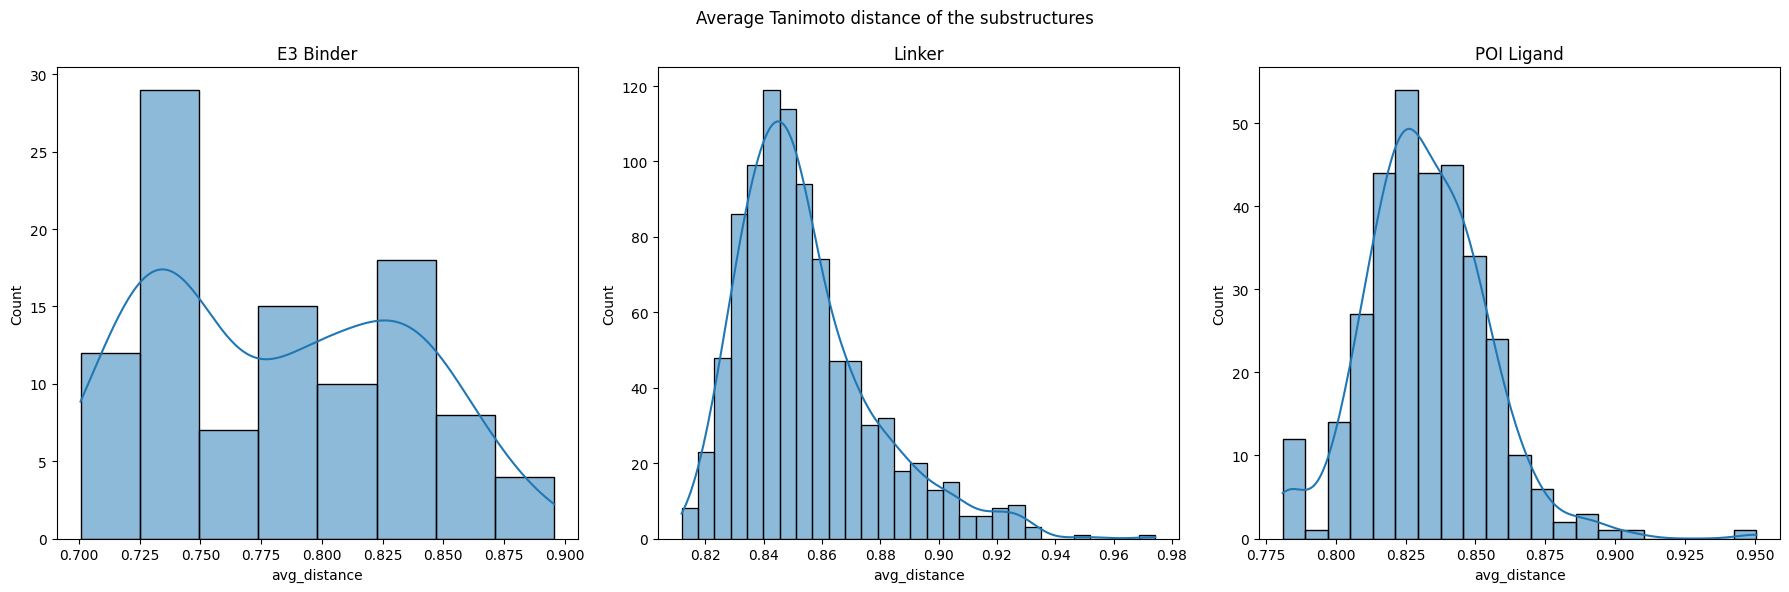

In [182]:
e3_num_subs = int(len(e3_df) * 0.3)
linker_num_subs = int(len(linker_df) * 0.3)
poi_num_subs = int(len(poi_df) * 0.3)
print(f'{e3_num_subs * linker_num_subs * poi_num_subs:,}')

# # Raise the "temperature" of the av_distance column, to be used as a probability
# e3_df['av_distance'] = 1 / e3_df['avg_distance']
# linker_df['av_distance'] = 1 / linker_df['avg_distance']
# poi_df['av_distance'] = 1 / poi_df['avg_distance']

# # Normalize the probabilities
# e3_df['av_distance'] = e3_df['av_distance'] / e3_df['av_distance'].sum()
# linker_df['av_distance'] = linker_df['av_distance'] / linker_df['av_distance'].sum()
# poi_df['av_distance'] = poi_df['av_distance'] / poi_df['av_distance'].sum()

# Plot the histograms of the average distances (with KDE too)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(e3_df['avg_distance'], kde=True, ax=axes[0])
sns.histplot(linker_df['avg_distance'], kde=True, ax=axes[1])
sns.histplot(poi_df['avg_distance'], kde=True, ax=axes[2])
axes[0].set_title('E3 Binder')
axes[1].set_title('Linker')
axes[2].set_title('POI Ligand')
plt.suptitle('Average Tanimoto distance of the substructures')
plt.tight_layout()
plt.show()

Add the respective IDs to the dictionaries:

In [203]:
e3_df['E3 Binder ID'] = e3_df['smiles'].map(protacs_splitted_with_directionality[['E3 Binder SMILES with direction', 'E3 Binder ID']].to_dict())
linker_df['Linker ID'] = linker_df['smiles'].map(protacs_splitted_with_directionality[['Linker SMILES with direction', 'Linker ID']].to_dict())
poi_df['POI Ligand ID'] = poi_df['smiles'].map(protacs_splitted_with_directionality[['POI Ligand SMILES with direction', 'POI Ligand ID']].to_dict())
safe_display(e3_df.head())

,smiles,fingerprint,avg_distance,count,E3 Binder ID
0,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",0.747319,NaN,NaN
1,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",0.700700,NaN,NaN
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",0.732216,NaN,NaN
3,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",0.837100,NaN,NaN
4,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",0.828753,NaN,NaN


In [201]:
import itertools

def get_train_test_subsets(df, test_fraction=0.3):
    max_num_substructs = int(len(df) * test_fraction)
    for_test = df.sort_values('avg_distance', ascending=False).iloc[:max_num_substructs]
    for_train = df.sort_values('avg_distance', ascending=False).iloc[max_num_substructs:]

    # Add all samples with same ID as the test set

    # Check that there are no same-ID E3 substructures in both training and testing sets:
    train_ids = set(for_train['smiles'])
    test_ids = set(for_test['smiles'])
    intersection = train_ids.intersection(test_ids)
    print(f'Number of E3 SMILESs that are in both the training and testing sets: {len(intersection)}')
    if intersection:
        raise ValueError('Same E3 SMILES in both training and testing sets')
    return for_train, for_test

def apply_temperature(df, column_name, temperature):
    # Apply softmax with temperature
    logits = np.array(df[column_name])
    adjusted_probs = np.exp(logits / temperature) / np.sum(np.exp(logits / temperature))
    return adjusted_probs

def sample_smiles(df, n: int = 1, weights: str = 'avg_distance') -> List[str]:
    return df.sample(n=n, replace=True, weights=weights, random_state=42)['smiles'].to_list()

e3_train, e3_test = get_train_test_subsets(e3_df)
linker_train, linker_test = get_train_test_subsets(linker_df)
poi_train, poi_test = get_train_test_subsets(poi_df)

max_samples = 10_000
max_test_perc = 0.2
max_test_size = int(max_samples * max_test_perc)
max_train_size = max_samples - max_test_size

# temperature = 0.01
# e3_test['weights'] = apply_temperature(e3_test, 'avg_distance', temperature)
# linker_test['weights'] = apply_temperature(linker_test, 'avg_distance', temperature)
# poi_test['weights'] = apply_temperature(poi_test, 'avg_distance', temperature)

# Sample the substructures
e3_train_smiles = sample_smiles(e3_train, n=max_train_size, weights=None)
e3_test_smiles = sample_smiles(e3_test, n=max_test_size, weights=None)
linker_train_smiles = sample_smiles(linker_train, n=max_train_size, weights=None)
linker_test_smiles = sample_smiles(linker_test, n=max_test_size, weights=None)
poi_train_smiles = sample_smiles(poi_train, n=max_train_size, weights=None)
poi_test_smiles = sample_smiles(poi_test, n=max_test_size, weights=None)

bond_types = ['single', 'double', 'triple']

# Generate the PROTACs by sampling the substructures
print('Generating training set...')
max_attempts_per_protac = 100
train_set = []
for e3, linker, poi in zip(e3_train_smiles, linker_train_smiles, poi_train_smiles):
    for e3_bond_type, poi_bond_type in itertools.product(bond_types, bond_types):
        try:
            merged_smiles, _ = reassemble_protac(
                poi_smiles=poi,
                linker_smiles=linker,
                e3_smiles=e3,
                e3_bond_type=e3_bond_type,
                poi_bond_type=poi_bond_type,
            )
            train_set.append({
                'PROTAC SMILES': merged_smiles,
                'E3 Binder SMILES with direction': e3,
                'Linker SMILES with direction': linker,
                'POI Ligand SMILES with direction': poi,
            })
        except Exception as e:
            continue

print('Generating test set...')
test_set = []
for e3, linker, poi in zip(e3_test_smiles, linker_test_smiles, poi_test_smiles):
    for e3_bond_type, poi_bond_type in itertools.product(bond_types, bond_types):
        try:
            merged_smiles, _ = reassemble_protac(
                poi_smiles=poi,
                linker_smiles=linker,
                e3_smiles=e3,
                e3_bond_type=e3_bond_type,
                poi_bond_type=poi_bond_type,
            )
            test_set.append({
                'PROTAC SMILES': merged_smiles,
                'E3 Binder SMILES with direction': e3,
                'Linker SMILES with direction': linker,
                'POI Ligand SMILES with direction': poi,
            })
        except Exception as e:
            pass

train_df = pd.DataFrame(train_set).drop_duplicates('PROTAC SMILES')
test_df = pd.DataFrame(test_set).drop_duplicates('PROTAC SMILES')

train_df = train_df.sample(n=max_train_size, replace=False, random_state=42)
test_df = test_df.sample(n=max_test_size, replace=False, random_state=42)

# Assign substructure IDs
train_df['E3 Binder ID'] = train_df['E3 Binder SMILES with direction'].map(protacs_splitted_with_directionality[['E3 Binder SMILES with direction', 'E3 Binder ID']].to_dict())
train_df['Linker ID'] = train_df['Linker SMILES with direction'].map(protacs_splitted_with_directionality[['Linker SMILES with direction', 'Linker ID']].to_dict())
train_df['POI Ligand ID'] = train_df['POI Ligand SMILES with direction'].map(protacs_splitted_with_directionality[['POI Ligand SMILES with direction', 'POI Ligand ID']].to_dict())

test_df['E3 Binder ID'] = test_df['E3 Binder SMILES with direction'].map(protacs_splitted_with_directionality[['E3 Binder SMILES with direction', 'E3 Binder ID']].to_dict())
test_df['Linker ID'] = test_df['Linker SMILES with direction'].map(protacs_splitted_with_directionality[['Linker SMILES with direction', 'Linker ID']].to_dict())
test_df['POI Ligand ID'] = test_df['POI Ligand SMILES with direction'].map(protacs_splitted_with_directionality[['POI Ligand SMILES with direction', 'POI Ligand ID']].to_dict())

# Save to CSV
os.makedirs(os.path.join(data_dir, 'datasets', 'hardest'), exist_ok=True)
train_df.to_csv(os.path.join(data_dir, 'datasets', 'hardest', 'train.csv'), index=False)
test_df.to_csv(os.path.join(data_dir, 'datasets', 'hardest', 'test.csv'), index=False)

print('-' * 80)
report_dataset(train_df, test_df)

# Print the average distance of the substructures in the test set
print('Average distance of the substructures in the test set:')
print(f'\t- E3: {e3_df[e3_df["smiles"].isin(test_df[e3_col])]["avg_distance"].mean():.3f}')
print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(test_df[linker_col])]["avg_distance"].mean():.3f}')
print(f'\t- POI: {poi_df[poi_df["smiles"].isin(test_df[poi_col])]["avg_distance"].mean():.3f}')

print('Average distance of the substructures in the training set:')
print(f'\t- E3: {e3_df[e3_df["smiles"].isin(train_df[e3_col])]["avg_distance"].mean():.3f}')
print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(train_df[linker_col])]["avg_distance"].mean():.3f}')
print(f'\t- POI: {poi_df[poi_df["smiles"].isin(train_df[poi_col])]["avg_distance"].mean():.3f}')

Number of E3 SMILESs that are in both the training and testing sets: 0
Number of E3 SMILESs that are in both the training and testing sets: 0
Number of E3 SMILESs that are in both the training and testing sets: 0
Generating training set...
Generating test set...
--------------------------------------------------------------------------------
Number of PROTACs in the training set: 8,000 (80.0%)
Number of PROTACs in the testing set: 2,000 (20.0%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 0
Number of entries with same Linker SMILES in the train and test sets: 0
Number of entries with same POI SMILES in the train and test sets: 0
Number of entries with same E3 ID in the train and test sets: 2000
Number of entries with same Linker ID in the train and test sets: 2000
Number of entries with same POI ID in the train and test sets: 2000
Average distance of the substructures in the test set:
	- E3:

### Deprecated Algorithm for the Hardest Split

In [155]:
# test_data = []
# protacs = protac_df[protac_df['smiles'].isin(train_df[protac_col])]
# for protac_smi in protacs.sort_values('avg_distance', ascending=False)['smiles'].tolist():
#     curr_test = train_df[train_df[protac_col] == protac_smi]
#     curr_test = pd.concat([
#         curr_test,
#         train_df[train_df[protac_id_col].isin(curr_test[protac_id_col])],
#     ]).drop_duplicates()

#     curr_test_perc = len(curr_test) / len(protacs_splitted_with_directionality)
#     total_test_perc = curr_test_perc
#     if test_data:
#         total_test_perc = (len(curr_test) + len(pd.concat(test_data))) / len(protacs_splitted_with_directionality)

#     perc_threshold = 0.05 # 0.015
#     max_test_perc = 0.10

#     if curr_test_perc > 0 and curr_test_perc <= perc_threshold and total_test_perc < max_test_perc:
#         # Print current size
#         # print(f'Number of isolated PROTACs: {len(curr_test):4d} ({curr_test_perc:.1%})')

#         # Append to the test data
#         test_data.append(curr_test)
#         test_protac_ids.extend(curr_test[protac_id_col].unique().tolist())
#         train_tmp = train_df[~train_df[protac_id_col].isin(test_protac_ids)].copy()
    
#     if total_test_perc >= max_test_perc:
#         break

# # Concatenate the test data
# test_tmp = pd.concat(test_data)

# train_tmp = pd.concat([train_df, train_tmp]).drop_duplicates()
# test_tmp = pd.concat([test_df, test_tmp]).drop_duplicates()

# report_dataset(train_tmp, test_tmp)
# print('-' * 80)
# # Print the average distance of the substructures in the test set
# print('Average distance of the substructures in the test set:')
# print(f'\t- E3: {e3_df[e3_df["smiles"].isin(test_tmp[e3_col])]["avg_distance"].mean():.3f}')
# print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(test_tmp[linker_col])]["avg_distance"].mean():.3f}')
# print(f'\t- POI: {poi_df[poi_df["smiles"].isin(test_tmp[poi_col])]["avg_distance"].mean():.3f}')

# print('Average distance of the substructures in the training set:')
# print(f'\t- E3: {e3_df[e3_df["smiles"].isin(train_tmp[e3_col])]["avg_distance"].mean():.3f}')
# print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(train_tmp[linker_col])]["avg_distance"].mean():.3f}')
# print(f'\t- POI: {poi_df[poi_df["smiles"].isin(train_tmp[poi_col])]["avg_distance"].mean():.3f}')